#Исследовательский анализ датасета после переработки

##Загрузка библиотек и написание собственных функций

In [43]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import scipy.cluster.hierarchy as sch
# from scipy.spatial.distance import squareform

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# import logging


pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore', module='pandas')
warnings.simplefilter(action='ignore', category=FutureWarning)

#ограничение вывода экспонинцеального вывода чисел
np.set_printoptions(suppress=True)

In [44]:
# pip install --upgrade gdown

In [45]:
#функция для изучения данных на аномальные значения и попуски
#функция принимает на вход DataFrame, выводит текстовые сообщения на консоль
def anomaly(data):
  #сли передан Series, преобразуем его в DataFrame
  if isinstance(data, pd.Series):
    data = data.to_frame()
  #выводим размер датасета
  print(f'Размер файла:{data.shape}')
  print('-'*100)
  #для вывода всех столбцов создаем цикл
  #выделяем в отдельную переменную названия столбцов
  column_data= data.columns
  #циклом перебираем все значения и выводим данные
  for c in column_data:
    #выводим все уникальные значения
    print(f'Уникальные значения показателя: {c}')
    print(data[c].unique())
    #считаем количество уникальных значений
    print(f'Количество уникальных значений: {data[c].nunique()}')
    #считаем количество всех значений
    print(f'Количество всех значений: {data[c].count()}')
    #считаем количество пропусков
    print(f'Количество пропусков в столбце {c}: {data[c].isna().sum()}')
    print('-'*100)

In [46]:
#функция для исследовательского анализа количественных данных
#функция принимает на вход DataFrame (количественные данные), выводит графики на консоль
def analisys_num(data):
    fig, axes = plt.subplots(1, 3, figsize=(10, 5))

    #настраиваем построение гистограммы
    axes[0].hist(data.dropna(), bins=20)
    axes[0].set_title('Гистограмма показателя')
    axes[0].set_xlabel('Значения показателя')
    #визуально выводим среднее значение и медиану
    axes[0].axvline(data.median(), color='b', linestyle='dashed', linewidth=2)
    axes[0].axvline(data.mean(), color='r', linestyle='solid', linewidth=2)
    axes[0].legend(['Медиана', 'Среднее', 'Мода'], prop={'size': 6})

    #постройка боксплота для данных
    axes[1].set_title('Боксплот показателя')
    axes[1].boxplot(data.dropna())
    #настройка скрипичной диаграммы
    axes[2].set_title('Скрипичная диаграмма показателя')
    axes[2].violinplot([data.dropna()], vert=False, widths=0.75,
                       showmeans=True, showmedians=True)
    plt.tight_layout()
    plt.show()
    #выводим статистику по показателю
    print('Показатели описательной статистики')
    print(data.describe())
    print(f'Мода в данных по показателю: {data.mode()}')

In [47]:
#функция для исследовательского анализа качественных данных с использованием круговой диаграммы
#функция принимает данные и считает их количество внутри каждого уникального значения,
#после выводит круговой график
#функция принимает на вход DataFrame, выводит графики на консоль
def analisys_cat_pie(data, labels=None):
    if labels is not None:
      data = data.map(labels)

    data.value_counts().plot(kind='pie', autopct='%.2f%%', figsize=(5, 5))
    plt.title('Круговая диаграмма показателя', size=10)
    plt.show()

In [48]:
#функция для исследовательского анализа качевтенных данных с использованием столбчатой диаграммы
#функция принимает данные и считает их количество внутри каждого уникального значения,
#после выводит столбчатую диаграмму
#функция принимает на вход DataFrame, выводит графики на консоль
def analisys_cat_plot(data):
    data.value_counts(ascending=True).plot(kind='bar', alpha=0.8)
    plt.title('Столбчатая диаграмма', size=15)
    plt.xlabel('Количество', size=12)
    plt.ylabel('Значения', size=12)
    plt.show()

In [49]:
#функция для вывода графика Lmplot
#функция принимает датасет и названия столбцов, по которым надо построить график
#функция принимает на вход DataFrame, выводит графики сообщения на консоль
def grafic(data, x, y):
    sns.lmplot(x=x, y=y, data=data)
    plt.title(f'Зависимость показателя {y} от показателя {x}', size=10)
    plt.xlabel(f'Показатель {x}', size=8)
    plt.ylabel(f'Показатель {y}', size=8)
    plt.show()

In [50]:
#функция для изучения распределния показателя в группах по целевому признаку
#функция принимает числовые данные для каждой группы и строит боксплот
def target_sigh(data, target_col, sign_col):
  sns.boxplot(x=target_col, y=sign_col, data=data)
  plt.title(f'Сравнение показателя {sign_col} у пациентов')
  plt.xlabel('Показатель')
  plt.show()

In [51]:
#функция для изучения распределения категориального фактора внутри группы целевого признака
#функция принимает количество категориальых данных в группе и строит гистограмму
def target_group(data, target_col, sign_col):
  plot_grouped_data(data, group_cols=[target_col, sign_col],
      rename_dict={
          'index': {0: 'Нет', 1: 'Есть'}
      }
  )
  plt.show()

##Первичная оценка и разметка данных

In [52]:
# ! gdown 1yqW_gtEn9IOmHQKqhLEMTI1xD9DxE-FM

In [53]:
df = pd.read_csv('data/etalon_df.csv')

In [54]:
df.head(2)

,study_ID,gender,age,rbc,rbc_ql,hgb,hgb_ql,hct,hct_ql,mcv,mcv_ql,mchc,mchc_ql,rdw,rdw_ql,rdv_sd,rdv_sd_ql,ret_abs,ret_abs_ql,cp,cp_ql,anisocytos,hypochromia,macrocytos,microcytos,poikilocytos,wbc,wbc_ql,ne_abs,ne_abs_ql,ly_abs,ly_abs_ql,mo_abs,mo_abs_ql,eo_abs,eo_abs_ql,ba_abs,ba_abs_ql,pal,pal_ql,seg,seg_ql,mxd_abs,mxd_abs_ql,plasma,plt,plt_ql,mpv,mpv_ql,pdw,pdw_ql,plcr,plcr_ql,soe,soe_ql,myelo,yunye,blasty,normoblast,normobl_abs,normobl_abs_ql,prolym,promyelo
0,05deb1af-cf40-11e9-80ba-901b0e633689_result_1802,0,87,2.21,-1.0,84.0,-1.0,26.3,-1.0,119.1,1.0,320.0,0.0,21.30,1.0,52.14,0.0,0.0,-1.0,1.14,1.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,6.50,0.0,1.30,0.0,1.50,1.0,0.20,0.0,0.00,0.0,3.00,0.0,67.00,0.0,0.52,0.0,0.0,100.0,-1.0,9.66,0.0,15.04,0.0,0.0,-1.0,12.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
1,05deb1af-cf40-11e9-80ba-901b0e633689_result_1803,0,87,1.91,-1.0,74.0,-1.0,23.6,-1.0,123.8,1.0,315.0,0.0,12.28,0.0,41.11,0.0,0.0,-1.0,0.91,0.0,0.0,0.0,0.0,0.0,0.0,9.1,0.0,4.12,0.0,1.59,0.0,0.52,0.0,0.13,0.0,0.01,0.0,2.61,0.0,66.94,0.0,0.69,0.0,0.0,264.4,0.0,7.85,0.0,15.50,0.0,0.0,-1.0,7.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1924 entries, 0 to 1923
Data columns (total 63 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_ID        1924 non-null   object 
 1   gender          1924 non-null   int64  
 2   age             1924 non-null   int64  
 3   rbc             1924 non-null   float64
 4   rbc_ql          1924 non-null   float64
 5   hgb             1924 non-null   float64
 6   hgb_ql          1924 non-null   float64
 7   hct             1924 non-null   float64
 8   hct_ql          1924 non-null   float64
 9   mcv             1924 non-null   float64
 10  mcv_ql          1924 non-null   float64
 11  mchc            1924 non-null   float64
 12  mchc_ql         1924 non-null   float64
 13  rdw             1924 non-null   float64
 14  rdw_ql          1924 non-null   float64
 15  rdv_sd          1924 non-null   float64
 16  rdv_sd_ql       1924 non-null   float64
 17  ret_abs         1924 non-null   f

In [56]:
# #создаем маску классов

# norm = (
#     (df['rbc_ql'] == 0) &
#     (df['hgb_ql'] == 0) &
#     (df['mcv_ql'] == 0) &
#     (df['mchc_ql'] == 0) &
#     (df['soe_ql'] == 0) &
#     # (data['htc_ql'] < 0) &
#     (df['wbc_ql'] == 0) &
#     (df['ne_abs_ql'] == 0) &
#     (df['ba_abs_ql'] == 0) &
#     (df['eo_abs_ql'] == 0) &
#     (df['ly_abs_ql'] == 0) &
#     (df['plt_ql'] == 0)
# )



# ac_anemia = (
#     (df['rbc_ql'] < 0) &
#     (df['hgb_ql'] < 0) &
#     (df['mcv_ql'] == 0) &
#     (df['mchc_ql'] == 0) &
#     #(df['soe_ql'] == 0) &
#     #(data['htc_ql'] < 0) &
#     #(df['wbc_ql'] == 0) &
#     #(df['ne_abs_ql'] == 0) &
#     #(df['ba_abs_ql'] == 0) &
#     #(df['ly_abs_ql'] == 0) &
#     (df['plt_ql'] >= 0)
# )

# chr_anemia = (
#     (df['rbc_ql'] < 0) &
#     (df['hgb_ql'] < 0) &
#     (df['mcv_ql'] < 0) &
#     (df['mchc_ql'] < 0) &
#     #(df['soe_ql'] == 0) &
#     #(data['htc_ql'] < 0) &
#     #(df['wbc_ql'] == 0) &
#     #(df['ne_abs_ql'] == 0) &
#     #(df['ba_abs_ql'] == 0) &
#     #(df['eo_abs_ql'] == 0) &
#     #(df['ly_abs_ql'] == 0) &
#     (df['plt_ql'] >= 0)
# )

# ac_infalm = (
#     # (df['rbc_ql'] == 0) &
#     # (df['hgb_ql'] == 0) &
#     # (df['mcv_ql'] == 0) &
#     # (df['mchc_ql'] == 0) &
#     (df['soe_ql'] > 0) &
#     # (data['htc_ql'] == 0) &
#     (df['wbc_ql'] > 0) &
#     (df['ne_abs_ql'] > 0) &
#     (df['ba_abs_ql'] == 0) &
#     (df['eo_abs_ql'] == 0) &
#     (df['ly_abs_ql'] == 0) &
#     (df['plt_ql'] >= 0)
# )

# chr_infalm = (
#     # (df['rbc_ql'] == 0) &
#     # (df['hgb_ql'] <= 0) &
#     # (df['mcv_ql'] == 0) &
#     # (df['mchc_ql'] == 0) &
#     # (df['soe_ql'] > 0) &
#     # (data['htc_ql'] == 0) &
#     (df['wbc_ql'] == 0) &
#     (df['ne_abs_ql'] > 0) &
#     (df['ba_abs_ql'] == 0) &
#     (df['eo_abs_ql'] == 0) &
#     (df['ly_abs_ql'] == 0) &
#     (df['plt_ql'] >= 0)
# )

# #0 - норма
# #1 - острая анемия
# #2 - хроническая анемия
# #3 - острое восполение
# #4 - хроническое восполение
# #5 - не установленных генез

# Задаем вероятности для каждого класса (должны суммироваться в 1)
probs = [0.2, 0.15, 0.3, 0.2, 0.1, 0.05]  # для 6 классов (0-5)

df['class'] = np.random.choice([0, 1, 2, 3, 4, 5], size=len(df), p=probs)

In [57]:
# Уберем столбцы с соответстветствием норме, чтоб не считать на входе по справочнику
df = df.loc[:, ~df.columns.str.endswith('_ql')] 

In [58]:
# df['class'] = 5

In [59]:
# df.loc[norm, 'class'] = 0
# df.loc[ac_anemia, 'class'] = 1
# df.loc[chr_anemia, 'class'] = 2
# df.loc[ac_infalm, 'class'] = 3
# df.loc[chr_infalm, 'class'] = 4

In [60]:
anomaly(df)

Размер файла:(1924, 40)
----------------------------------------------------------------------------------------------------
Уникальные значения показателя: study_ID
['05deb1af-cf40-11e9-80ba-901b0e633689_result_1802'
 '05deb1af-cf40-11e9-80ba-901b0e633689_result_1803'
 '05deb1af-cf40-11e9-80ba-901b0e633689_result_1805' ...
 'ffdf0ad3-bb5b-11ee-ab6f-0050568844e6_result_2593'
 'ffdf0ad3-bb5b-11ee-ab6f-0050568844e6_result_2594'
 'ffdf0ad3-bb5b-11ee-ab6f-0050568844e6_result_2595']
Количество уникальных значений: 1924
Количество всех значений: 1924
Количество пропусков в столбце study_ID: 0
----------------------------------------------------------------------------------------------------
Уникальные значения показателя: gender
[0 1]
Количество уникальных значений: 2
Количество всех значений: 1924
Количество пропусков в столбце gender: 0
----------------------------------------------------------------------------------------------------
Уникальные значения показателя: age
[87 51 86 77 73 7

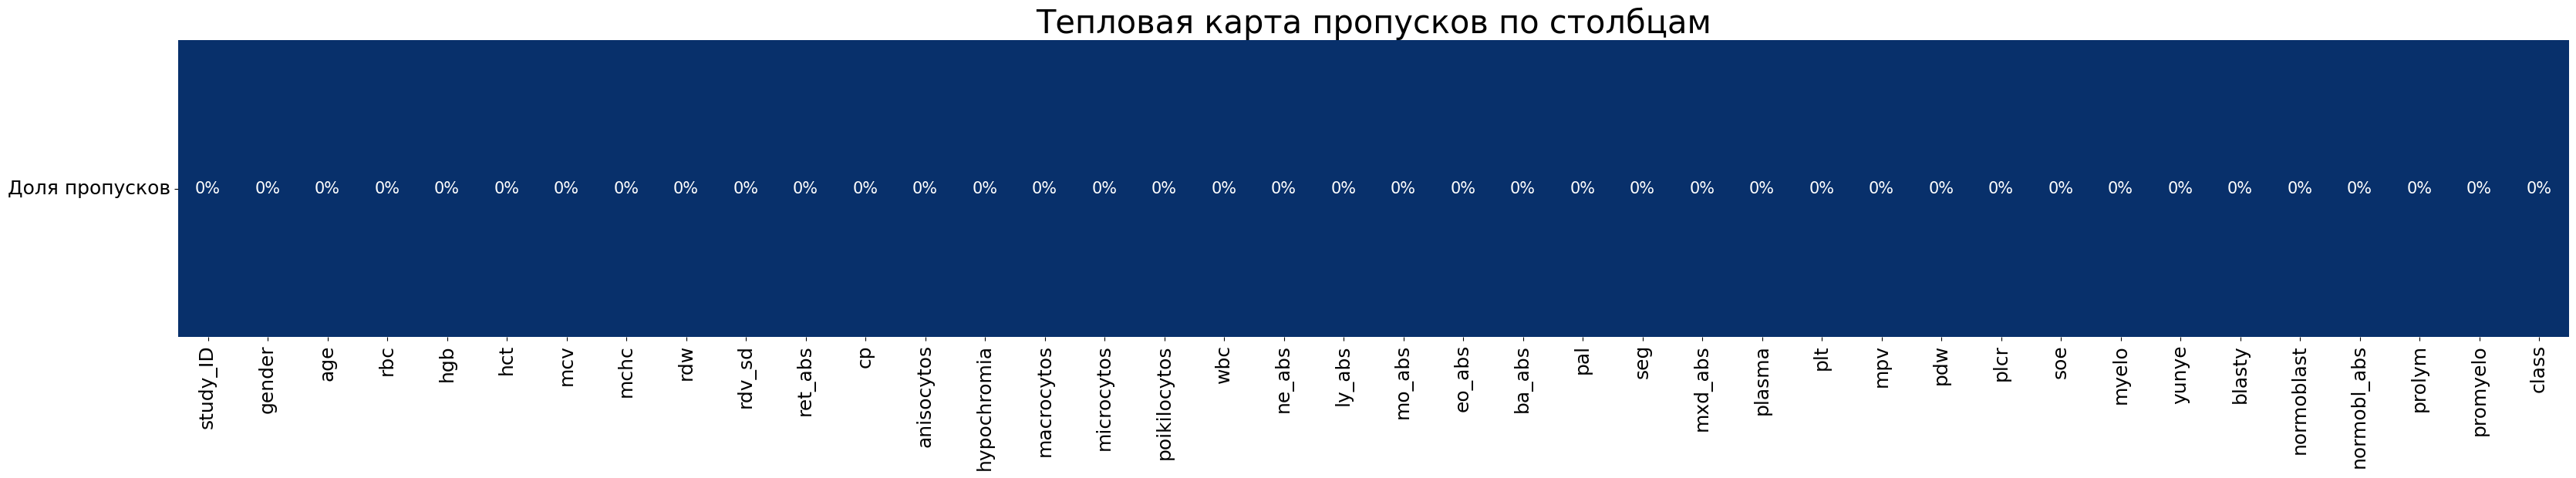

In [61]:
mask = df.isna()

prop_missings = mask.sum()/mask.count()

#преобразуем в DataFrame для построения тепловой карты
df_prop_missings = pd.DataFrame(prop_missings.values.reshape(1, -1),
                                columns=prop_missings.index,
                                index=['Доля пропусков'])

#тепловая карта пропусков
plt.figure(figsize=(40, 5))
sns.heatmap(df_prop_missings, annot=True, fmt='.0%',
            cmap='Blues_r', cbar=False, annot_kws={'fontsize': 15})
plt.title("Тепловая карта пропусков по столбцам", fontsize=30)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18, rotation=0)
plt.show()

##Исследовательский анализ

In [62]:
df = df.drop('study_ID', axis = 1)

In [63]:
df.head(2)

,gender,age,rbc,hgb,hct,mcv,mchc,rdw,rdv_sd,ret_abs,cp,anisocytos,hypochromia,macrocytos,microcytos,poikilocytos,wbc,ne_abs,ly_abs,mo_abs,eo_abs,ba_abs,pal,seg,mxd_abs,plasma,plt,mpv,pdw,plcr,soe,myelo,yunye,blasty,normoblast,normobl_abs,prolym,promyelo,class
0,0,87,2.21,84.0,26.3,119.1,320.0,21.30,52.14,0.0,1.14,0.0,0.0,0.0,0.0,0.0,10.0,6.50,1.30,1.50,0.20,0.00,3.00,67.00,0.52,0.0,100.0,9.66,15.04,0.0,12.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,3
1,0,87,1.91,74.0,23.6,123.8,315.0,12.28,41.11,0.0,0.91,0.0,0.0,0.0,0.0,0.0,9.1,4.12,1.59,0.52,0.13,0.01,2.61,66.94,0.69,0.0,264.4,7.85,15.50,0.0,7.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [64]:
df.columns

Index(['gender', 'age', 'rbc', 'hgb', 'hct', 'mcv', 'mchc', 'rdw', 'rdv_sd',
       'ret_abs', 'cp', 'anisocytos', 'hypochromia', 'macrocytos',
       'microcytos', 'poikilocytos', 'wbc', 'ne_abs', 'ly_abs', 'mo_abs',
       'eo_abs', 'ba_abs', 'pal', 'seg', 'mxd_abs', 'plasma', 'plt', 'mpv',
       'pdw', 'plcr', 'soe', 'myelo', 'yunye', 'blasty', 'normoblast',
       'normobl_abs', 'prolym', 'promyelo', 'class'],
      dtype='object')

In [65]:
bool_col = ['gender', 'anisocytos', 'hypochromia',
            'macrocytos','microcytos', 'poikilocytos',
            'normoblast', 'promyelo']

num_col = ['age', 'rbc', 'hgb', 'hct', 'mcv', 'mchc', 'rdw',
           'rdv_sd', 'ret_abs', 'cp', 'wbc', 'ne_abs', 'ly_abs',
           'mo_abs', 'eo_abs', 'ba_abs', 'pal', 'seg', 'mxd_abs',
           'plasma', 'plt', 'mpv', 'pdw', 'plcr', 'soe', 'myelo',
           'yunye', 'blasty', 'normobl_abs']

# cat_col = ['class', 'rbc_ql',  'hgb_ql', 'hct_ql', 'mcv_ql',  'mchc_ql', 'rdw_ql',
#            'rdv_sd_ql', 'ret_abs_ql', 'cp_ql', 'wbc_ql', 'ne_abs_ql',  'ly_abs_ql',
#            'mo_abs_ql',  'eo_abs_ql',  'ba_abs_ql', 'pal_ql', 'seg_ql', 'mxd_abs_ql',
#            'plt_ql',  'mpv_ql',  'pdw_ql',  'plcr_ql', 'soe_ql', 'normobl_abs_ql']

cat_col = ['class']

Исследовательский анализ age


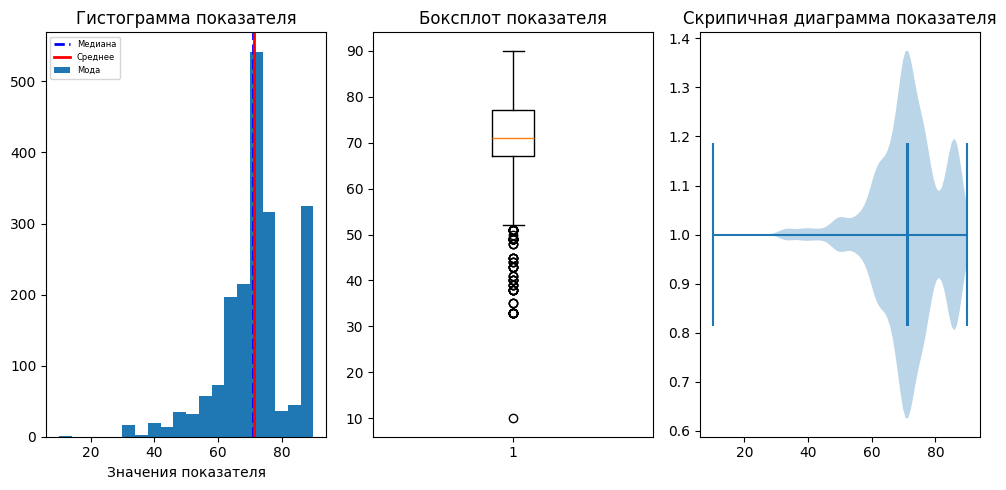

Показатели описательной статистики
count    1924.000000
mean       71.284823
std        10.661431
min        10.000000
25%        67.000000
50%        71.000000
75%        77.000000
max        90.000000
Name: age, dtype: float64
Мода в данных по показателю: 0    71
Name: age, dtype: int64
----------------------------------------------------------------------------------------------------
Исследовательский анализ rbc


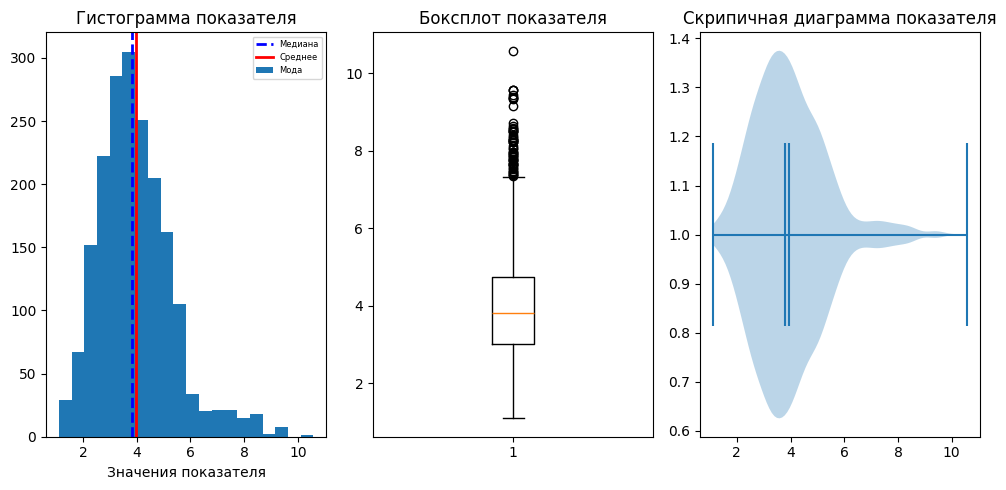

Показатели описательной статистики
count    1924.000000
mean        3.955686
std         1.385585
min         1.100000
25%         3.020000
50%         3.810000
75%         4.740000
max        10.580000
Name: rbc, dtype: float64
Мода в данных по показателю: 0    3.53
1    3.55
2    3.61
Name: rbc, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ hgb


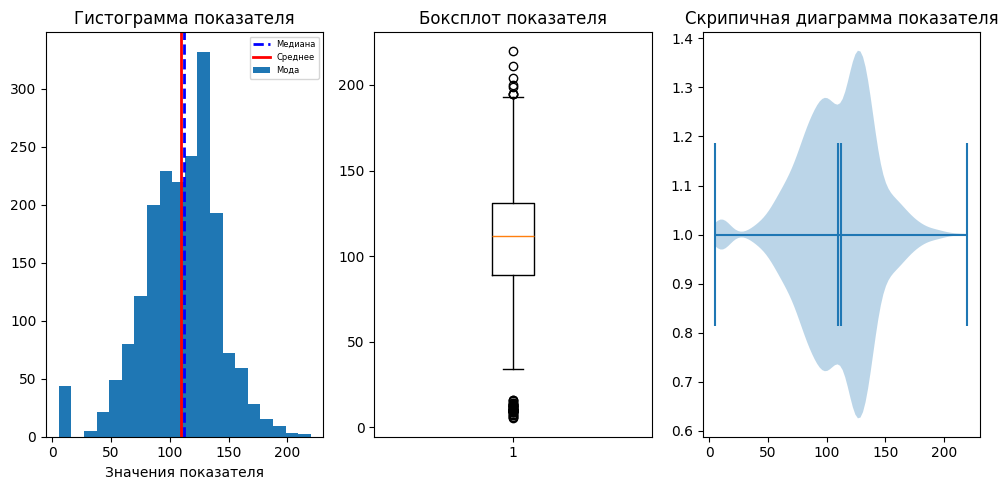

Показатели описательной статистики
count    1924.000000
mean      109.388950
std        32.461647
min         5.340000
25%        89.000000
50%       112.000000
75%       131.000000
max       220.000000
Name: hgb, dtype: float64
Мода в данных по показателю: 0    111.0
Name: hgb, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ hct


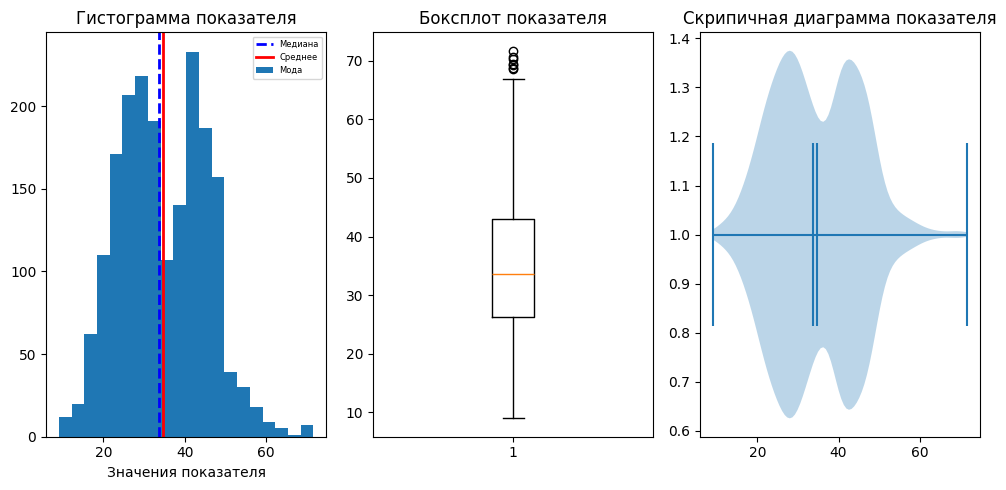

Показатели описательной статистики
count    1924.000000
mean       34.654984
std        10.620694
min         9.000000
25%        26.200000
50%        33.700000
75%        43.000000
max        71.700000
Name: hct, dtype: float64
Мода в данных по показателю: 0    28.0
Name: hct, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ mcv


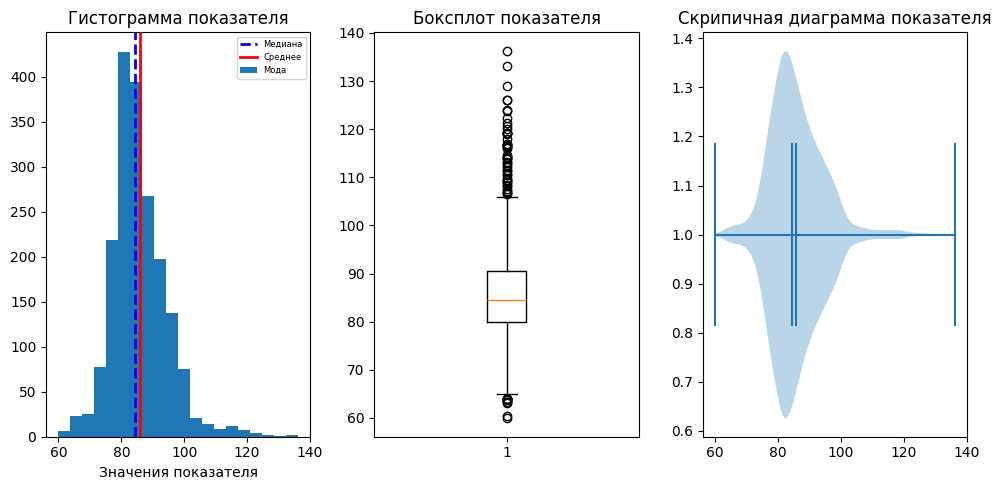

Показатели описательной статистики
count    1924.000000
mean       85.813015
std         8.905736
min        59.900000
25%        80.000000
50%        84.480000
75%        90.525000
max       136.300000
Name: mcv, dtype: float64
Мода в данных по показателю: 0    81.0
Name: mcv, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ mchc


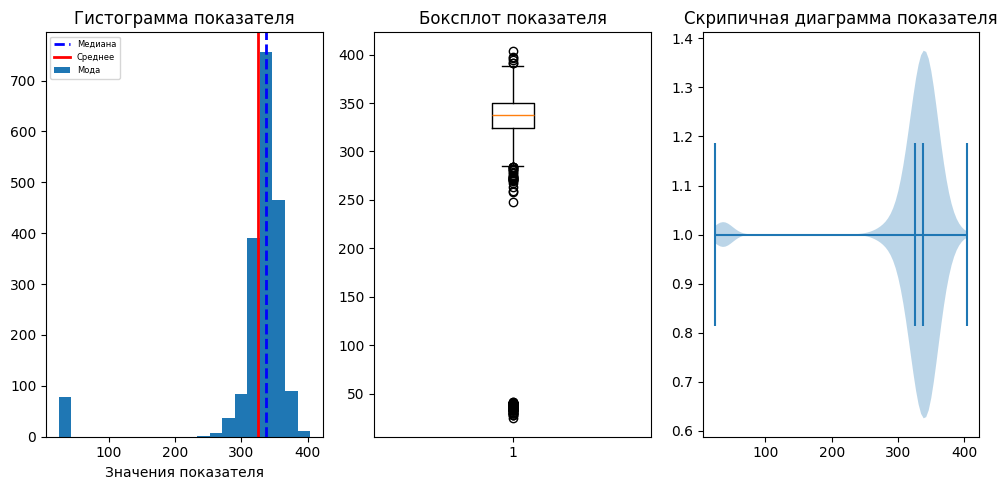

Показатели описательной статистики
count    1924.000000
mean      325.419636
std        62.922951
min        24.400000
25%       324.000000
50%       338.000000
75%       350.000000
max       404.000000
Name: mchc, dtype: float64
Мода в данных по показателю: 0    344.0
Name: mchc, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ rdw


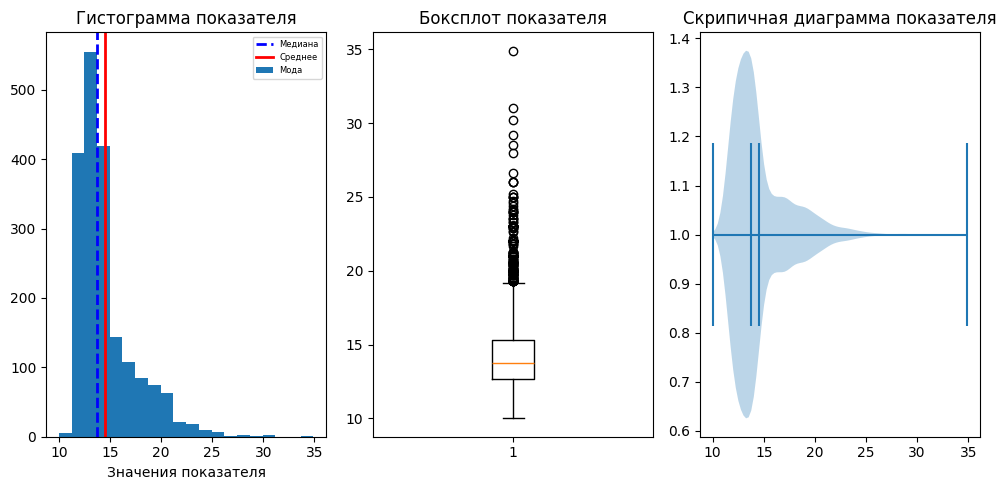

Показатели описательной статистики
count    1924.000000
mean       14.546788
std         2.866527
min        10.000000
25%        12.657500
50%        13.720000
75%        15.300000
max        34.900000
Name: rdw, dtype: float64
Мода в данных по показателю: 0    14.0
Name: rdw, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ rdv_sd


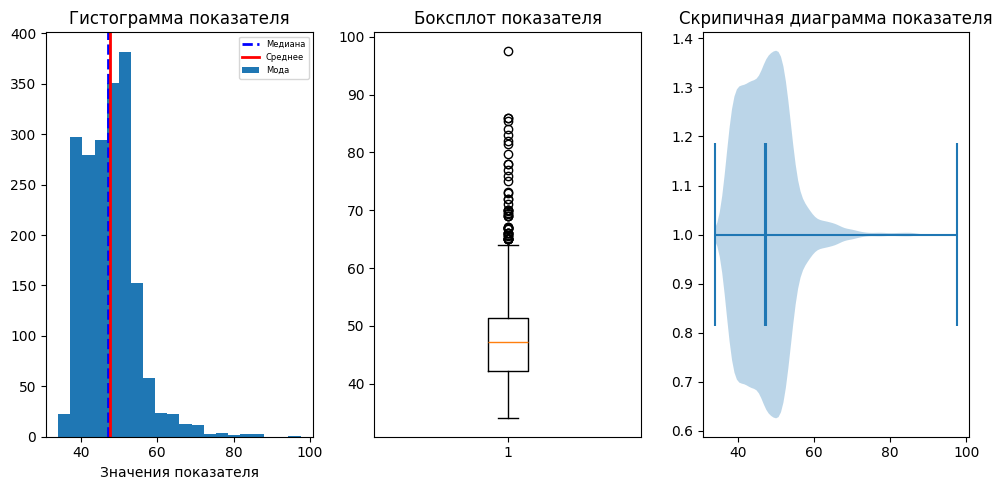

Показатели описательной статистики
count    1924.000000
mean       47.508015
std         7.079567
min        34.000000
25%        42.210000
50%        47.150000
75%        51.305000
max        97.600000
Name: rdv_sd, dtype: float64
Мода в данных по показателю: 0    52.0
Name: rdv_sd, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ ret_abs


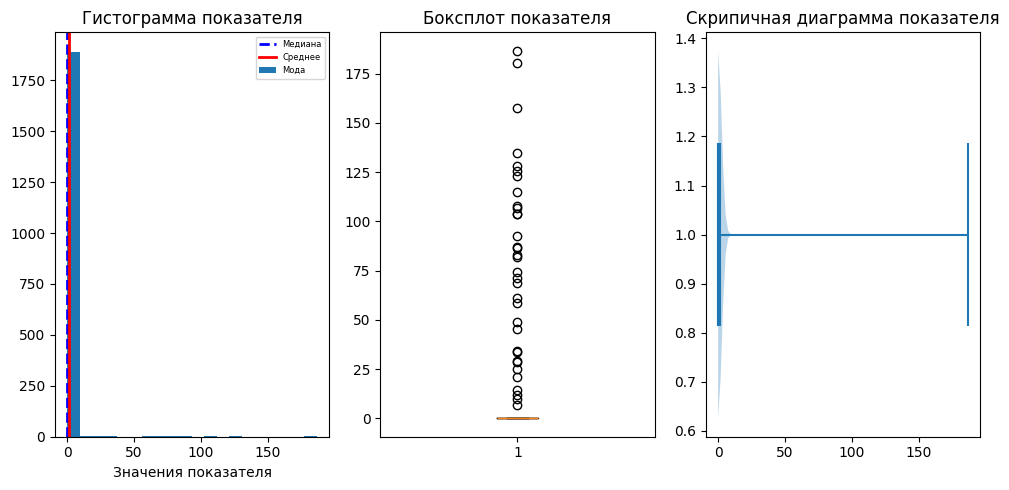

Показатели описательной статистики
count    1924.000000
mean        1.375156
std        12.094051
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       186.600000
Name: ret_abs, dtype: float64
Мода в данных по показателю: 0    0.0
Name: ret_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ cp


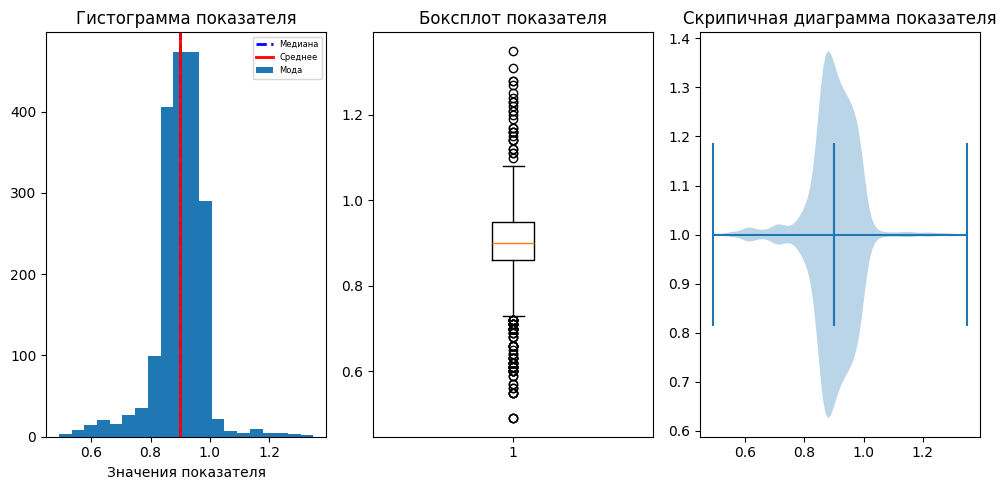

Показатели описательной статистики
count    1924.000000
mean        0.900785
std         0.084304
min         0.490000
25%         0.860000
50%         0.900000
75%         0.950000
max         1.350000
Name: cp, dtype: float64
Мода в данных по показателю: 0    0.86
Name: cp, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ wbc


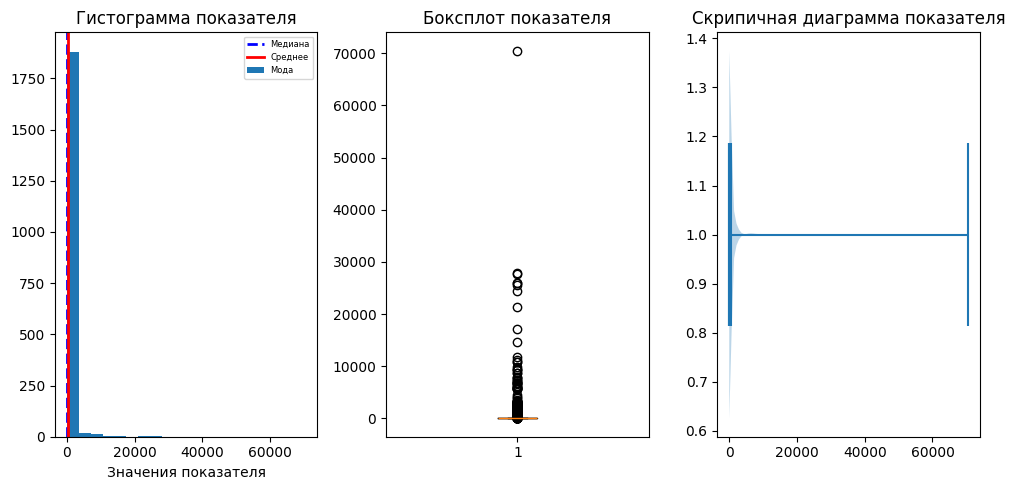

Показатели описательной статистики
count     1924.000000
mean       467.052853
std       2523.011525
min          0.000000
25%          4.680000
50%          7.735000
75%         13.477500
max      70500.000000
Name: wbc, dtype: float64
Мода в данных по показателю: 0    1.0
Name: wbc, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ ne_abs


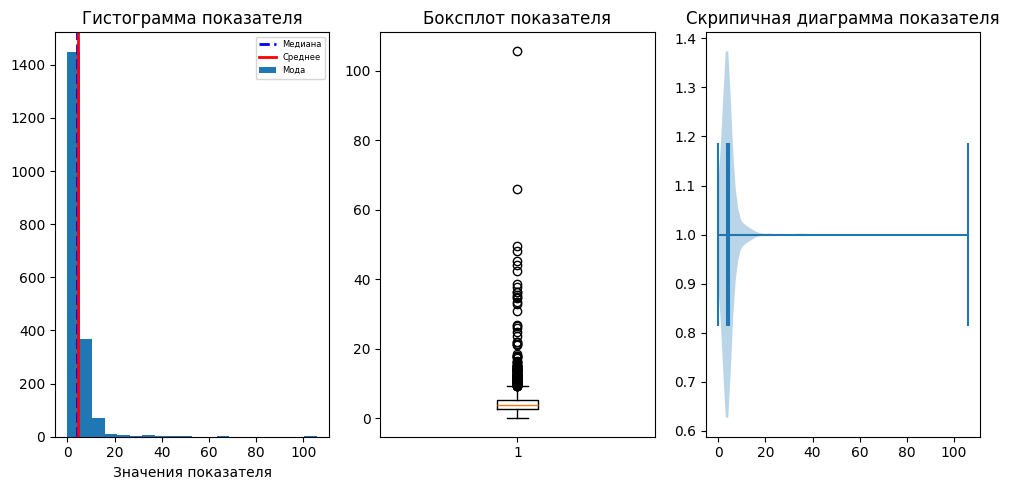

Показатели описательной статистики
count    1924.000000
mean        4.676752
std         5.112347
min         0.000000
25%         2.620000
50%         3.900000
75%         5.270000
max       105.700000
Name: ne_abs, dtype: float64
Мода в данных по показателю: 0    4.4
Name: ne_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ ly_abs


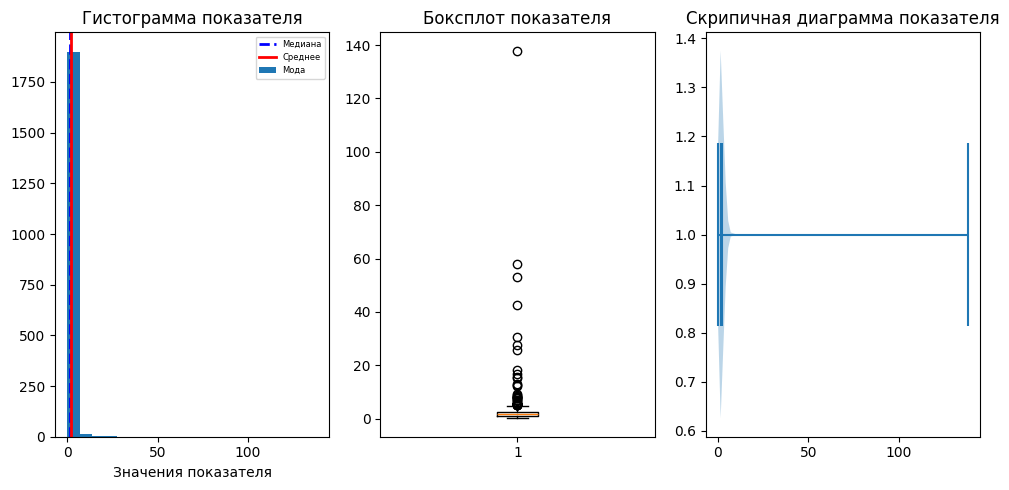

Показатели описательной статистики
count    1924.000000
mean        2.225437
std         4.084520
min         0.100000
25%         1.060000
50%         1.700000
75%         2.630000
max       137.900000
Name: ly_abs, dtype: float64
Мода в данных по показателю: 0    1.0
Name: ly_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ mo_abs


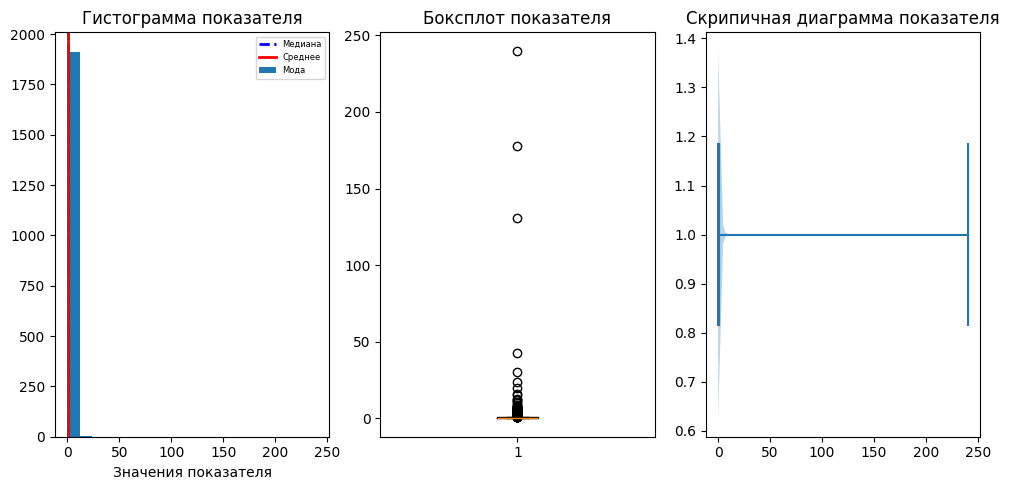

Показатели описательной статистики
count    1924.000000
mean        0.885930
std         7.603788
min         0.000000
25%         0.200000
50%         0.370000
75%         0.560000
max       239.930000
Name: mo_abs, dtype: float64
Мода в данных по показателю: 0    0.2
Name: mo_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ eo_abs


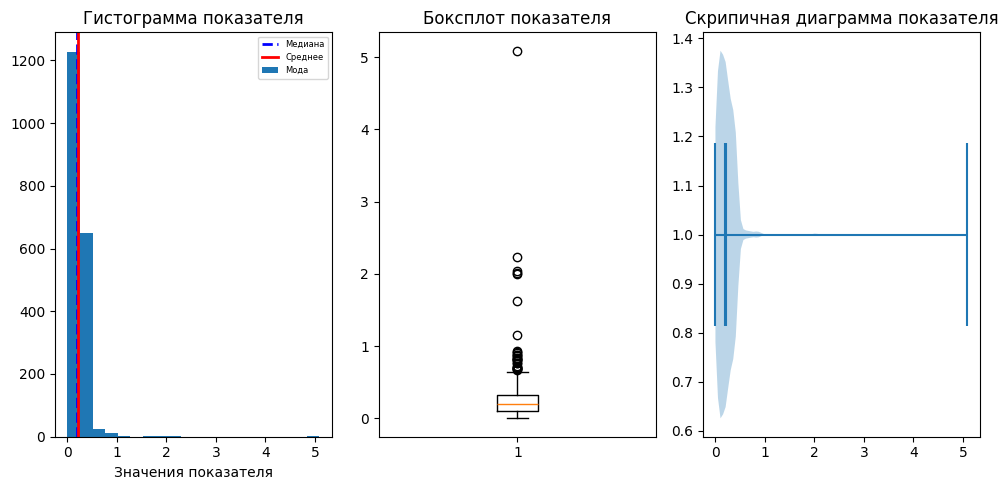

Показатели описательной статистики
count    1924.000000
mean        0.218576
std         0.207139
min         0.000000
25%         0.100000
50%         0.200000
75%         0.320000
max         5.090000
Name: eo_abs, dtype: float64
Мода в данных по показателю: 0    0.0
Name: eo_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ ba_abs


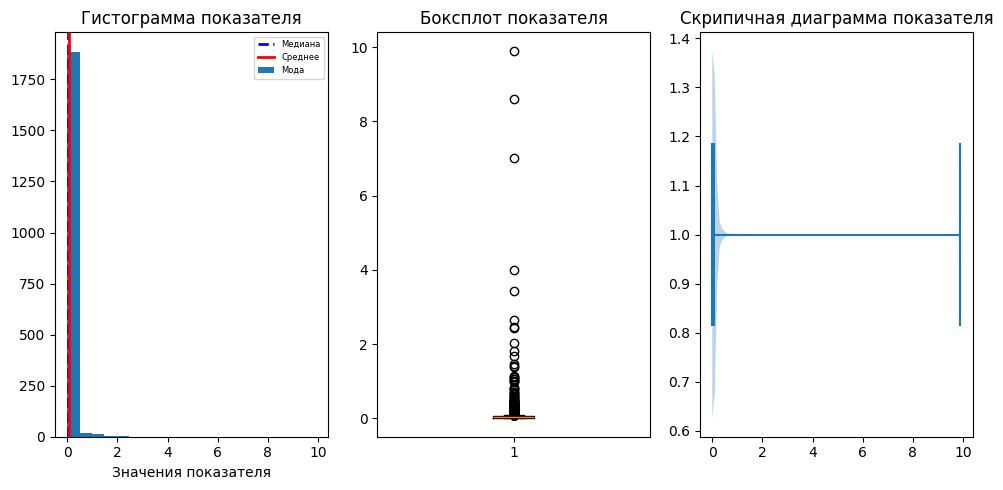

Показатели описательной статистики
count    1924.000000
mean        0.087225
std         0.393870
min         0.000000
25%         0.020000
50%         0.030000
75%         0.050000
max         9.900000
Name: ba_abs, dtype: float64
Мода в данных по показателю: 0    0.02
Name: ba_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ pal


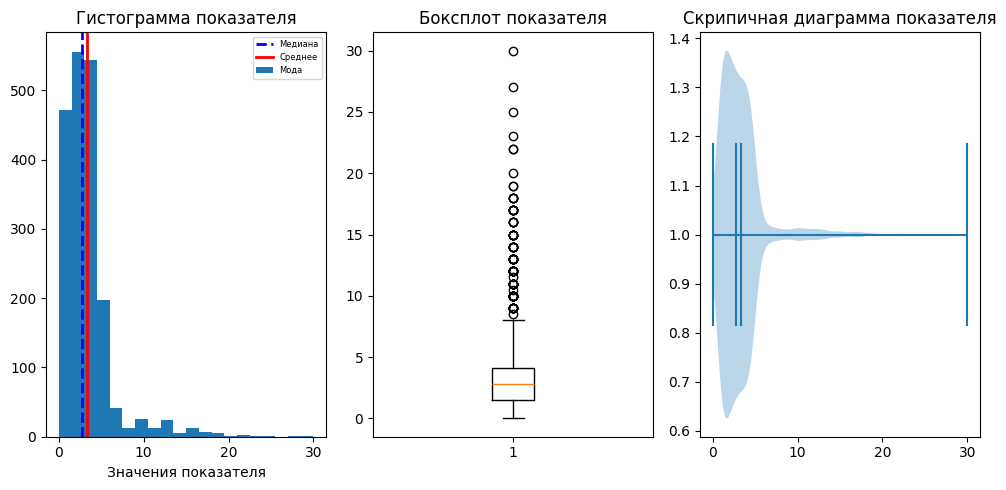

Показатели описательной статистики
count    1924.000000
mean        3.330156
std         2.938691
min         0.000000
25%         1.517500
50%         2.770000
75%         4.120000
max        30.000000
Name: pal, dtype: float64
Мода в данных по показателю: 0    1.0
Name: pal, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ seg


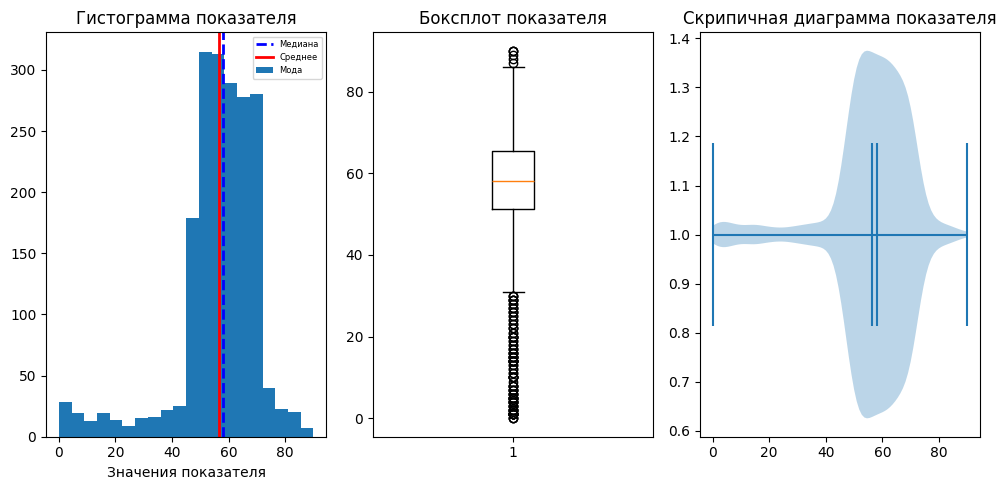

Показатели описательной статистики
count    1924.000000
mean       56.454662
std        14.298451
min         0.000000
25%        51.320000
50%        58.000000
75%        65.455000
max        90.000000
Name: seg, dtype: float64
Мода в данных по показателю: 0    60.0
Name: seg, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ mxd_abs


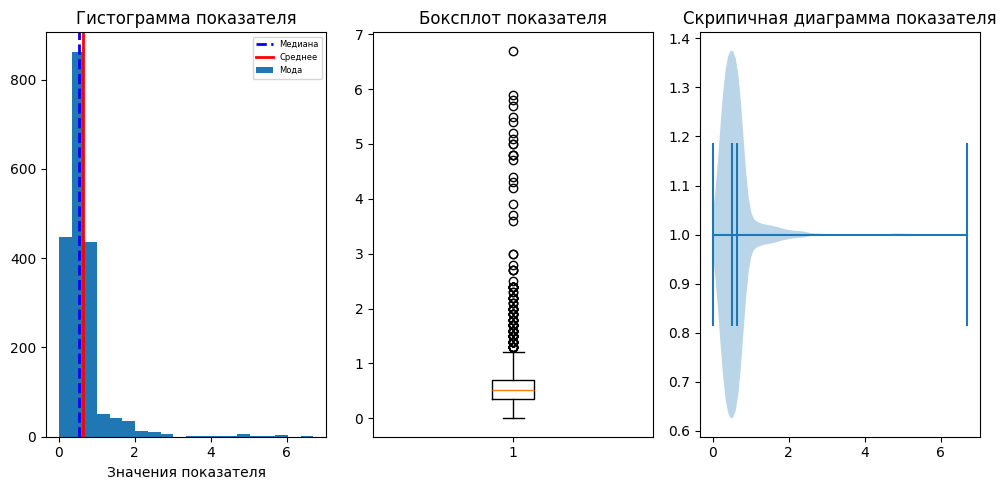

Показатели описательной статистики
count    1924.000000
mean        0.637001
std         0.589475
min         0.000000
25%         0.350000
50%         0.520000
75%         0.700000
max         6.700000
Name: mxd_abs, dtype: float64
Мода в данных по показателю: 0    0.7
Name: mxd_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ plasma


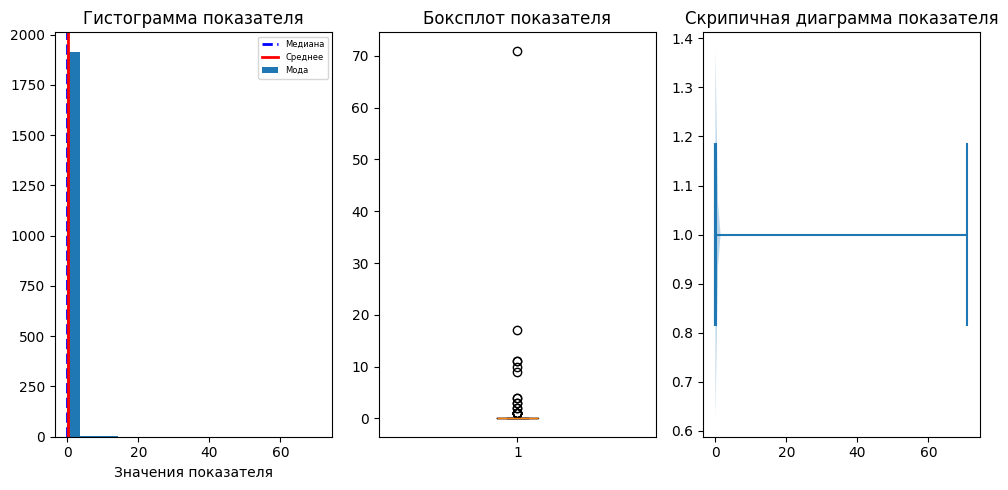

Показатели описательной статистики
count    1924.000000
mean        0.080561
std         1.737673
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        71.000000
Name: plasma, dtype: float64
Мода в данных по показателю: 0    0.0
Name: plasma, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ plt


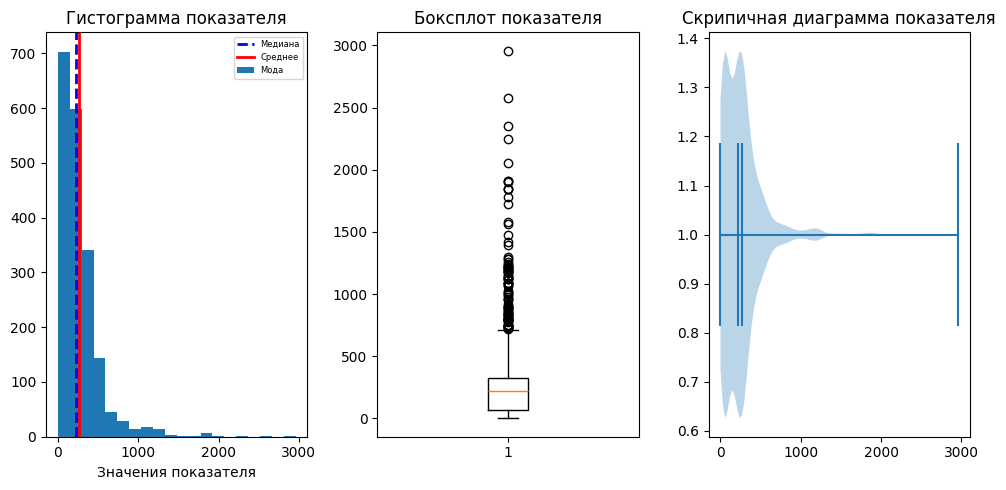

Показатели описательной статистики
count    1924.000000
mean      264.461788
std       275.091246
min         0.000000
25%        71.000000
50%       221.900000
75%       328.475000
max      2958.000000
Name: plt, dtype: float64
Мода в данных по показателю: 0    36.0
Name: plt, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ mpv


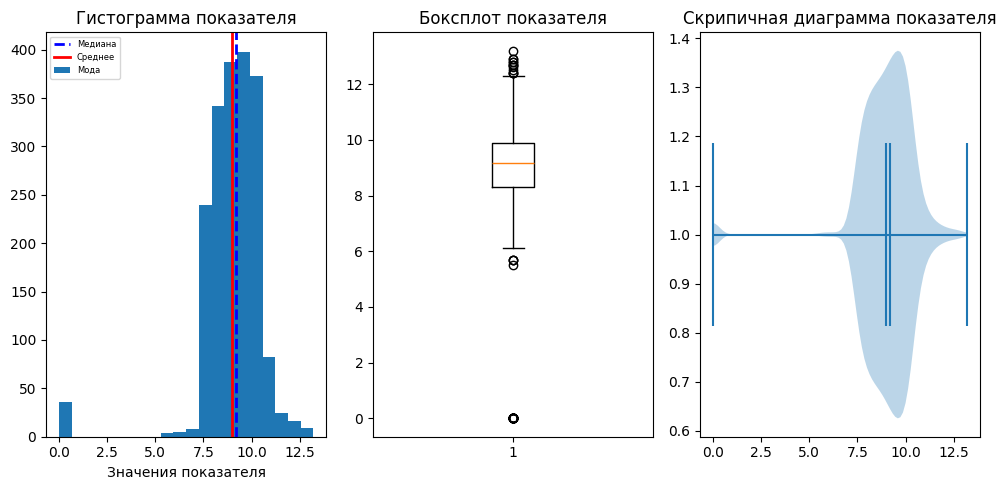

Показатели описательной статистики
count    1924.000000
mean        8.990130
std         1.622442
min         0.000000
25%         8.300000
50%         9.170000
75%         9.900000
max        13.200000
Name: mpv, dtype: float64
Мода в данных по показателю: 0    9.9
Name: mpv, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ pdw


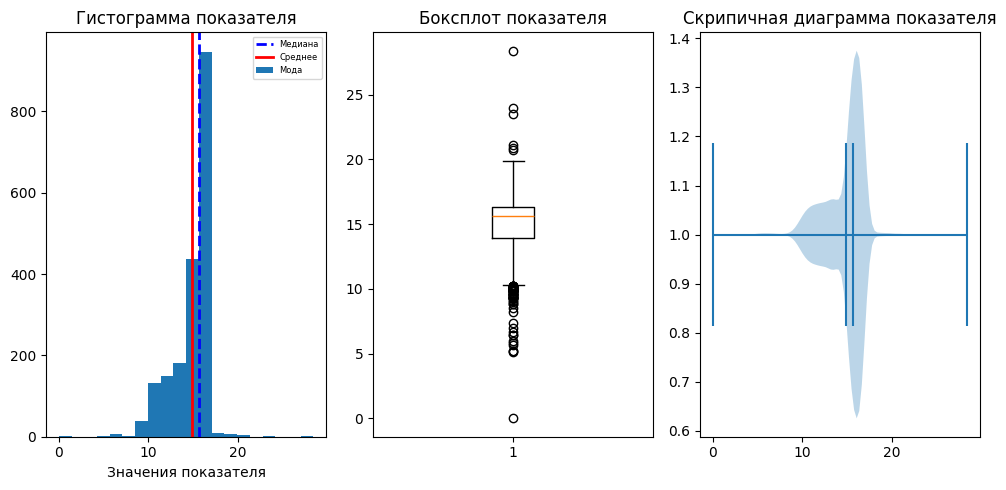

Показатели описательной статистики
count    1924.000000
mean       14.900702
std         2.168487
min         0.000000
25%        13.900000
50%        15.630000
75%        16.320000
max        28.400000
Name: pdw, dtype: float64
Мода в данных по показателю: 0    11.7
1    13.5
Name: pdw, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ plcr


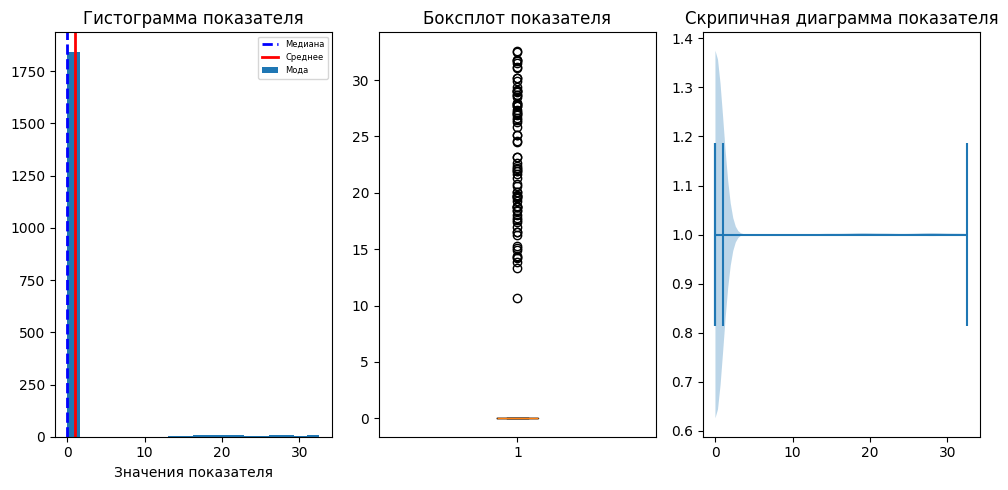

Показатели описательной статистики
count    1924.000000
mean        0.962422
std         4.763007
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        32.600000
Name: plcr, dtype: float64
Мода в данных по показателю: 0    0.0
Name: plcr, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ soe


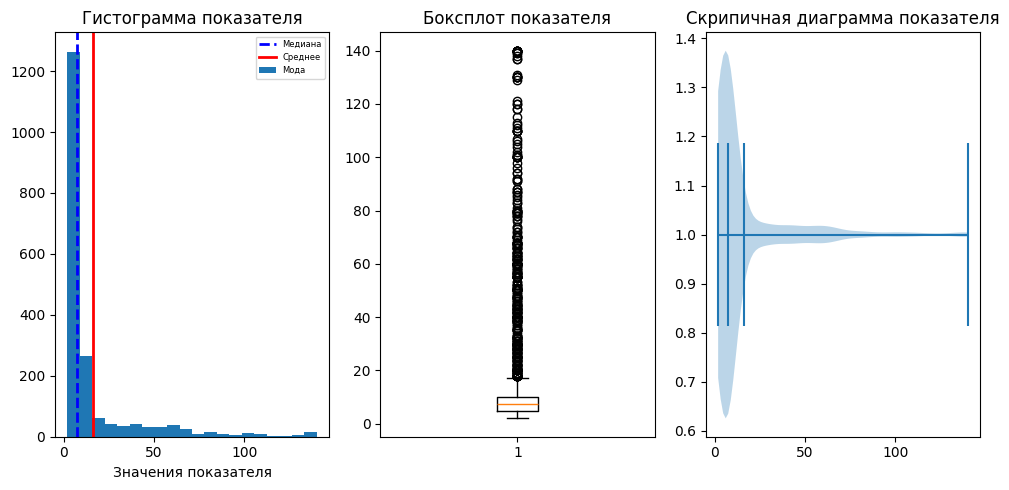

Показатели описательной статистики
count    1924.000000
mean       16.056622
std        24.190584
min         2.000000
25%         4.640000
50%         7.245000
75%         9.960000
max       140.000000
Name: soe, dtype: float64
Мода в данных по показателю: 0    4.0
Name: soe, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ myelo


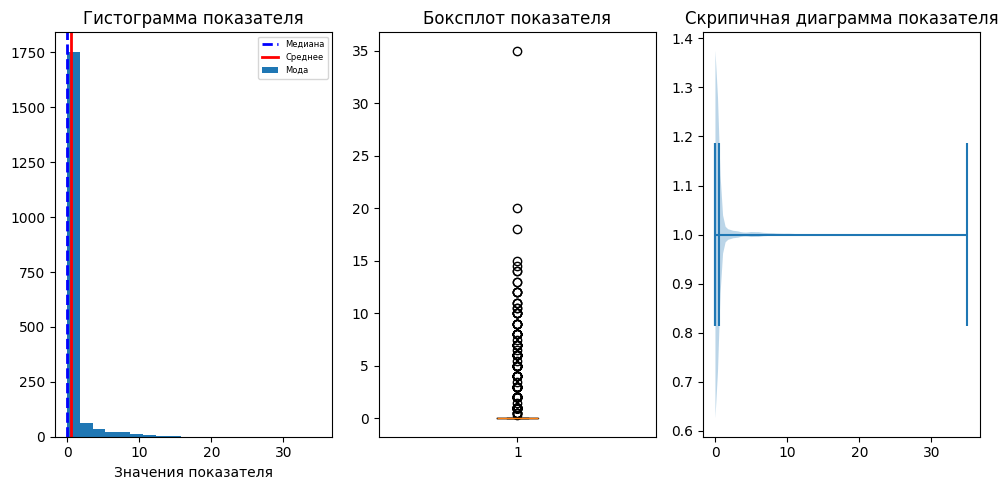

Показатели описательной статистики
count    1924.000000
mean        0.542775
std         2.041212
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        35.000000
Name: myelo, dtype: float64
Мода в данных по показателю: 0    0.0
Name: myelo, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ yunye


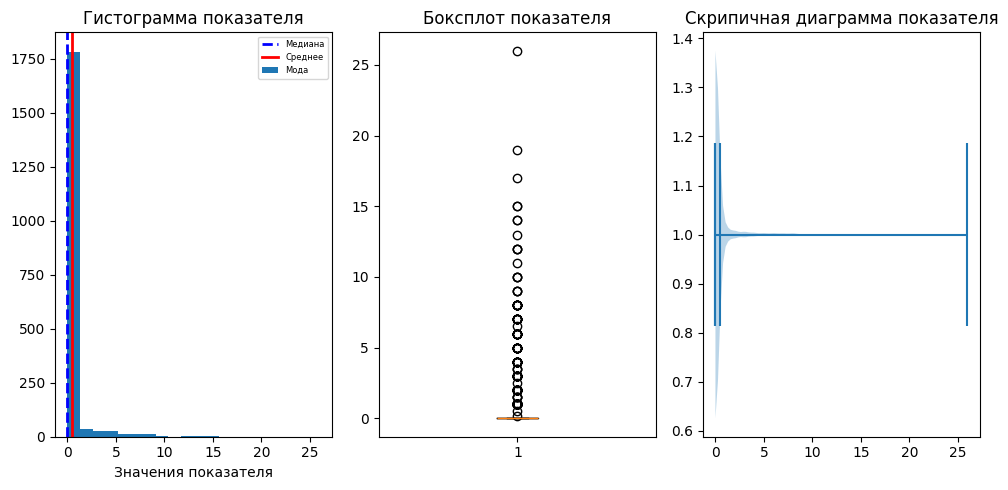

Показатели описательной статистики
count    1924.000000
mean        0.426819
std         1.732356
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        26.000000
Name: yunye, dtype: float64
Мода в данных по показателю: 0    0.0
Name: yunye, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ blasty


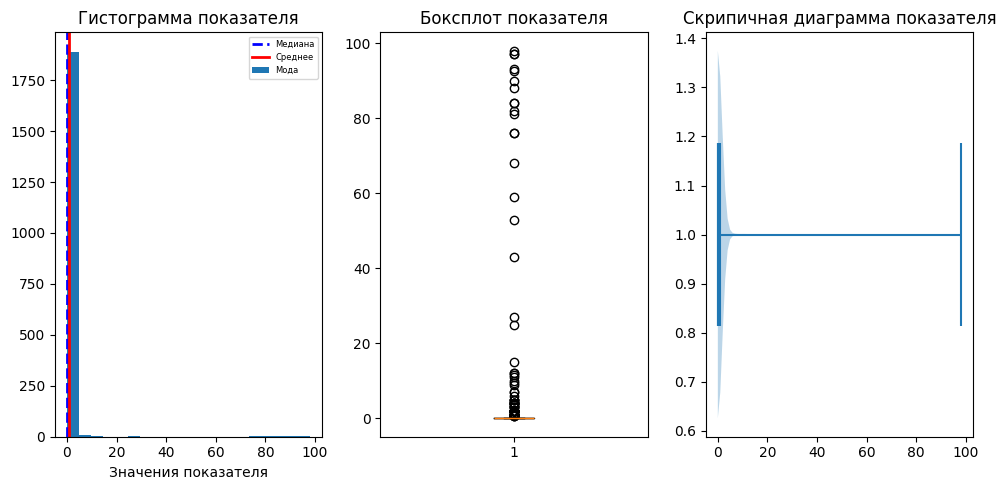

Показатели описательной статистики
count    1924.000000
mean        0.875520
std         7.720832
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        98.000000
Name: blasty, dtype: float64
Мода в данных по показателю: 0    0.0
Name: blasty, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ normobl_abs


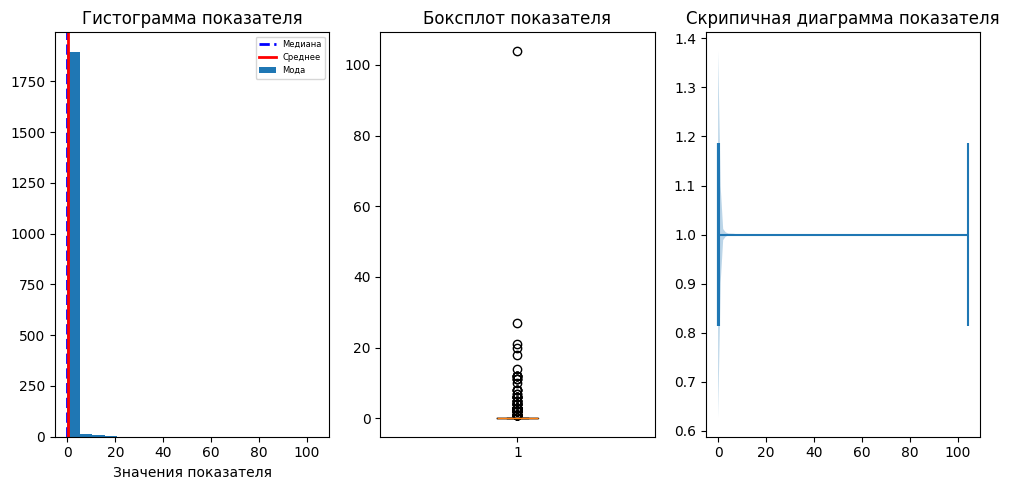

Показатели описательной статистики
count    1924.000000
mean        0.312890
std         2.797336
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       104.000000
Name: normobl_abs, dtype: float64
Мода в данных по показателю: 0    0.0
Name: normobl_abs, dtype: float64
----------------------------------------------------------------------------------------------------


In [66]:
for col in num_col:
  print(f'Исследовательский анализ {col}')
  analisys_num(df[col])
  print('-'*100)

Исследовательский анализ показателя class


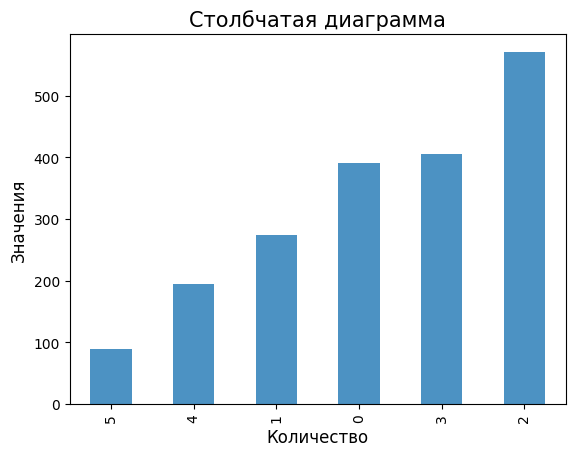

----------------------------------------------------------------------------------------------------


In [68]:
for col in cat_col:
  print(f'Исследовательский анализ показателя {col}')
  analisys_cat_plot(df[col])
  print('-'*100)

Исследовательский анализ показателя gender


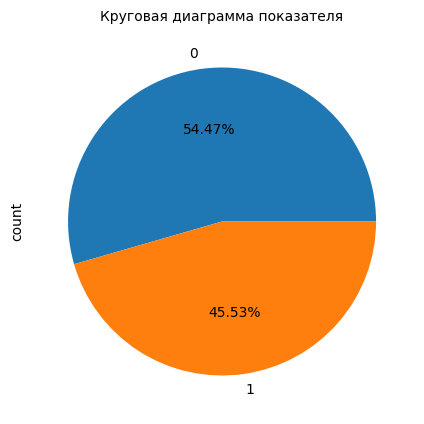

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя anisocytos


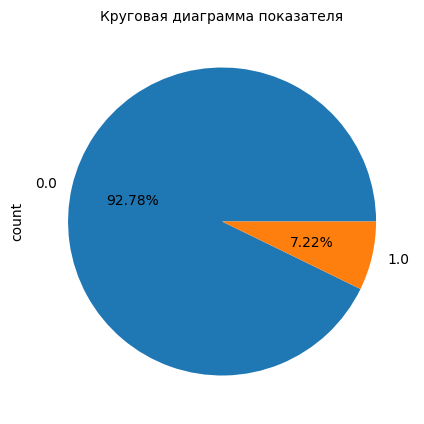

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя hypochromia


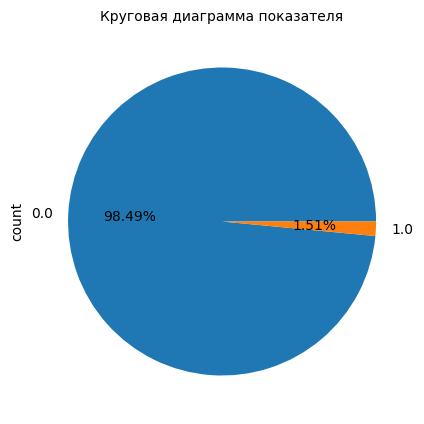

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя macrocytos


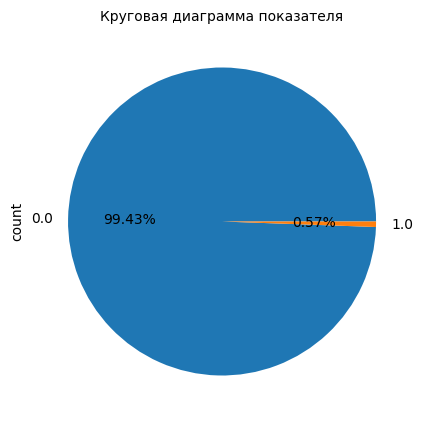

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя microcytos


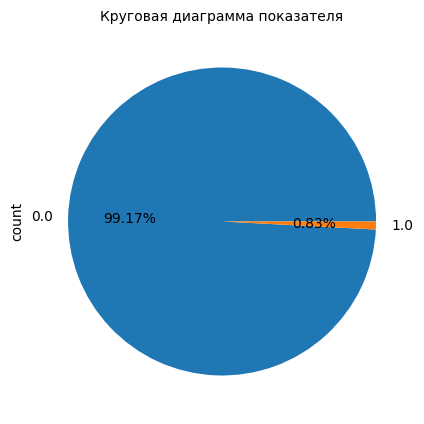

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя poikilocytos


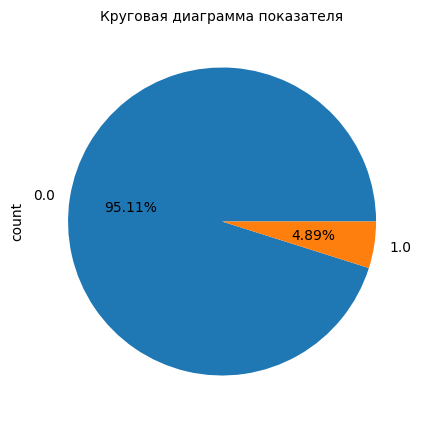

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя normoblast


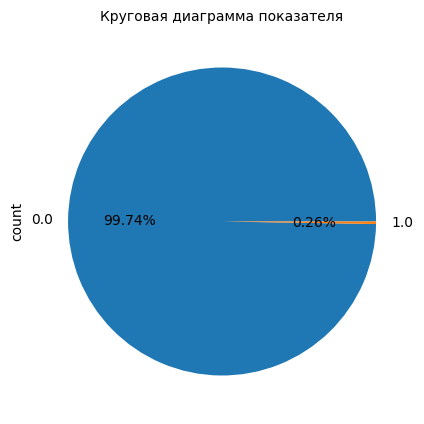

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя promyelo


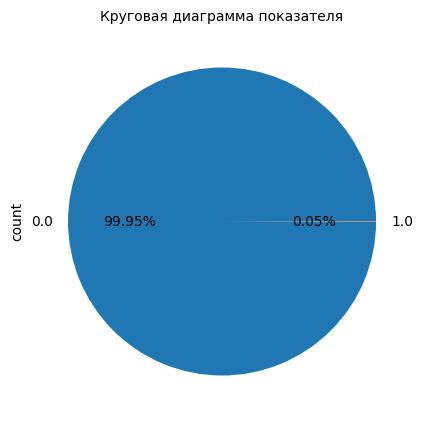

----------------------------------------------------------------------------------------------------


In [69]:
for col in bool_col:
  print(f'Исследовательский анализ показателя {col}')
  analisys_cat_pie(df[col])
  print('-'*100)

##Корреляционный анализ

In [70]:
#подготовка данных для корреляции
#в связи с большим количеством данных и разбросом данных, не расчитать ранги
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [71]:
# QR-разложение для определения ранга корреляции
Q, R = np.linalg.qr(scaled_data)
qr_rank = np.sum(np.abs(R.diagonal()) > 1e-10)

print(f'QR-разложение (количество линейно независимых столбцов): {qr_rank}')
print(f'Количество столбцов: {scaled_data.shape[1]}')

QR-разложение (количество линейно независимых столбцов): 39
Количество столбцов: 39


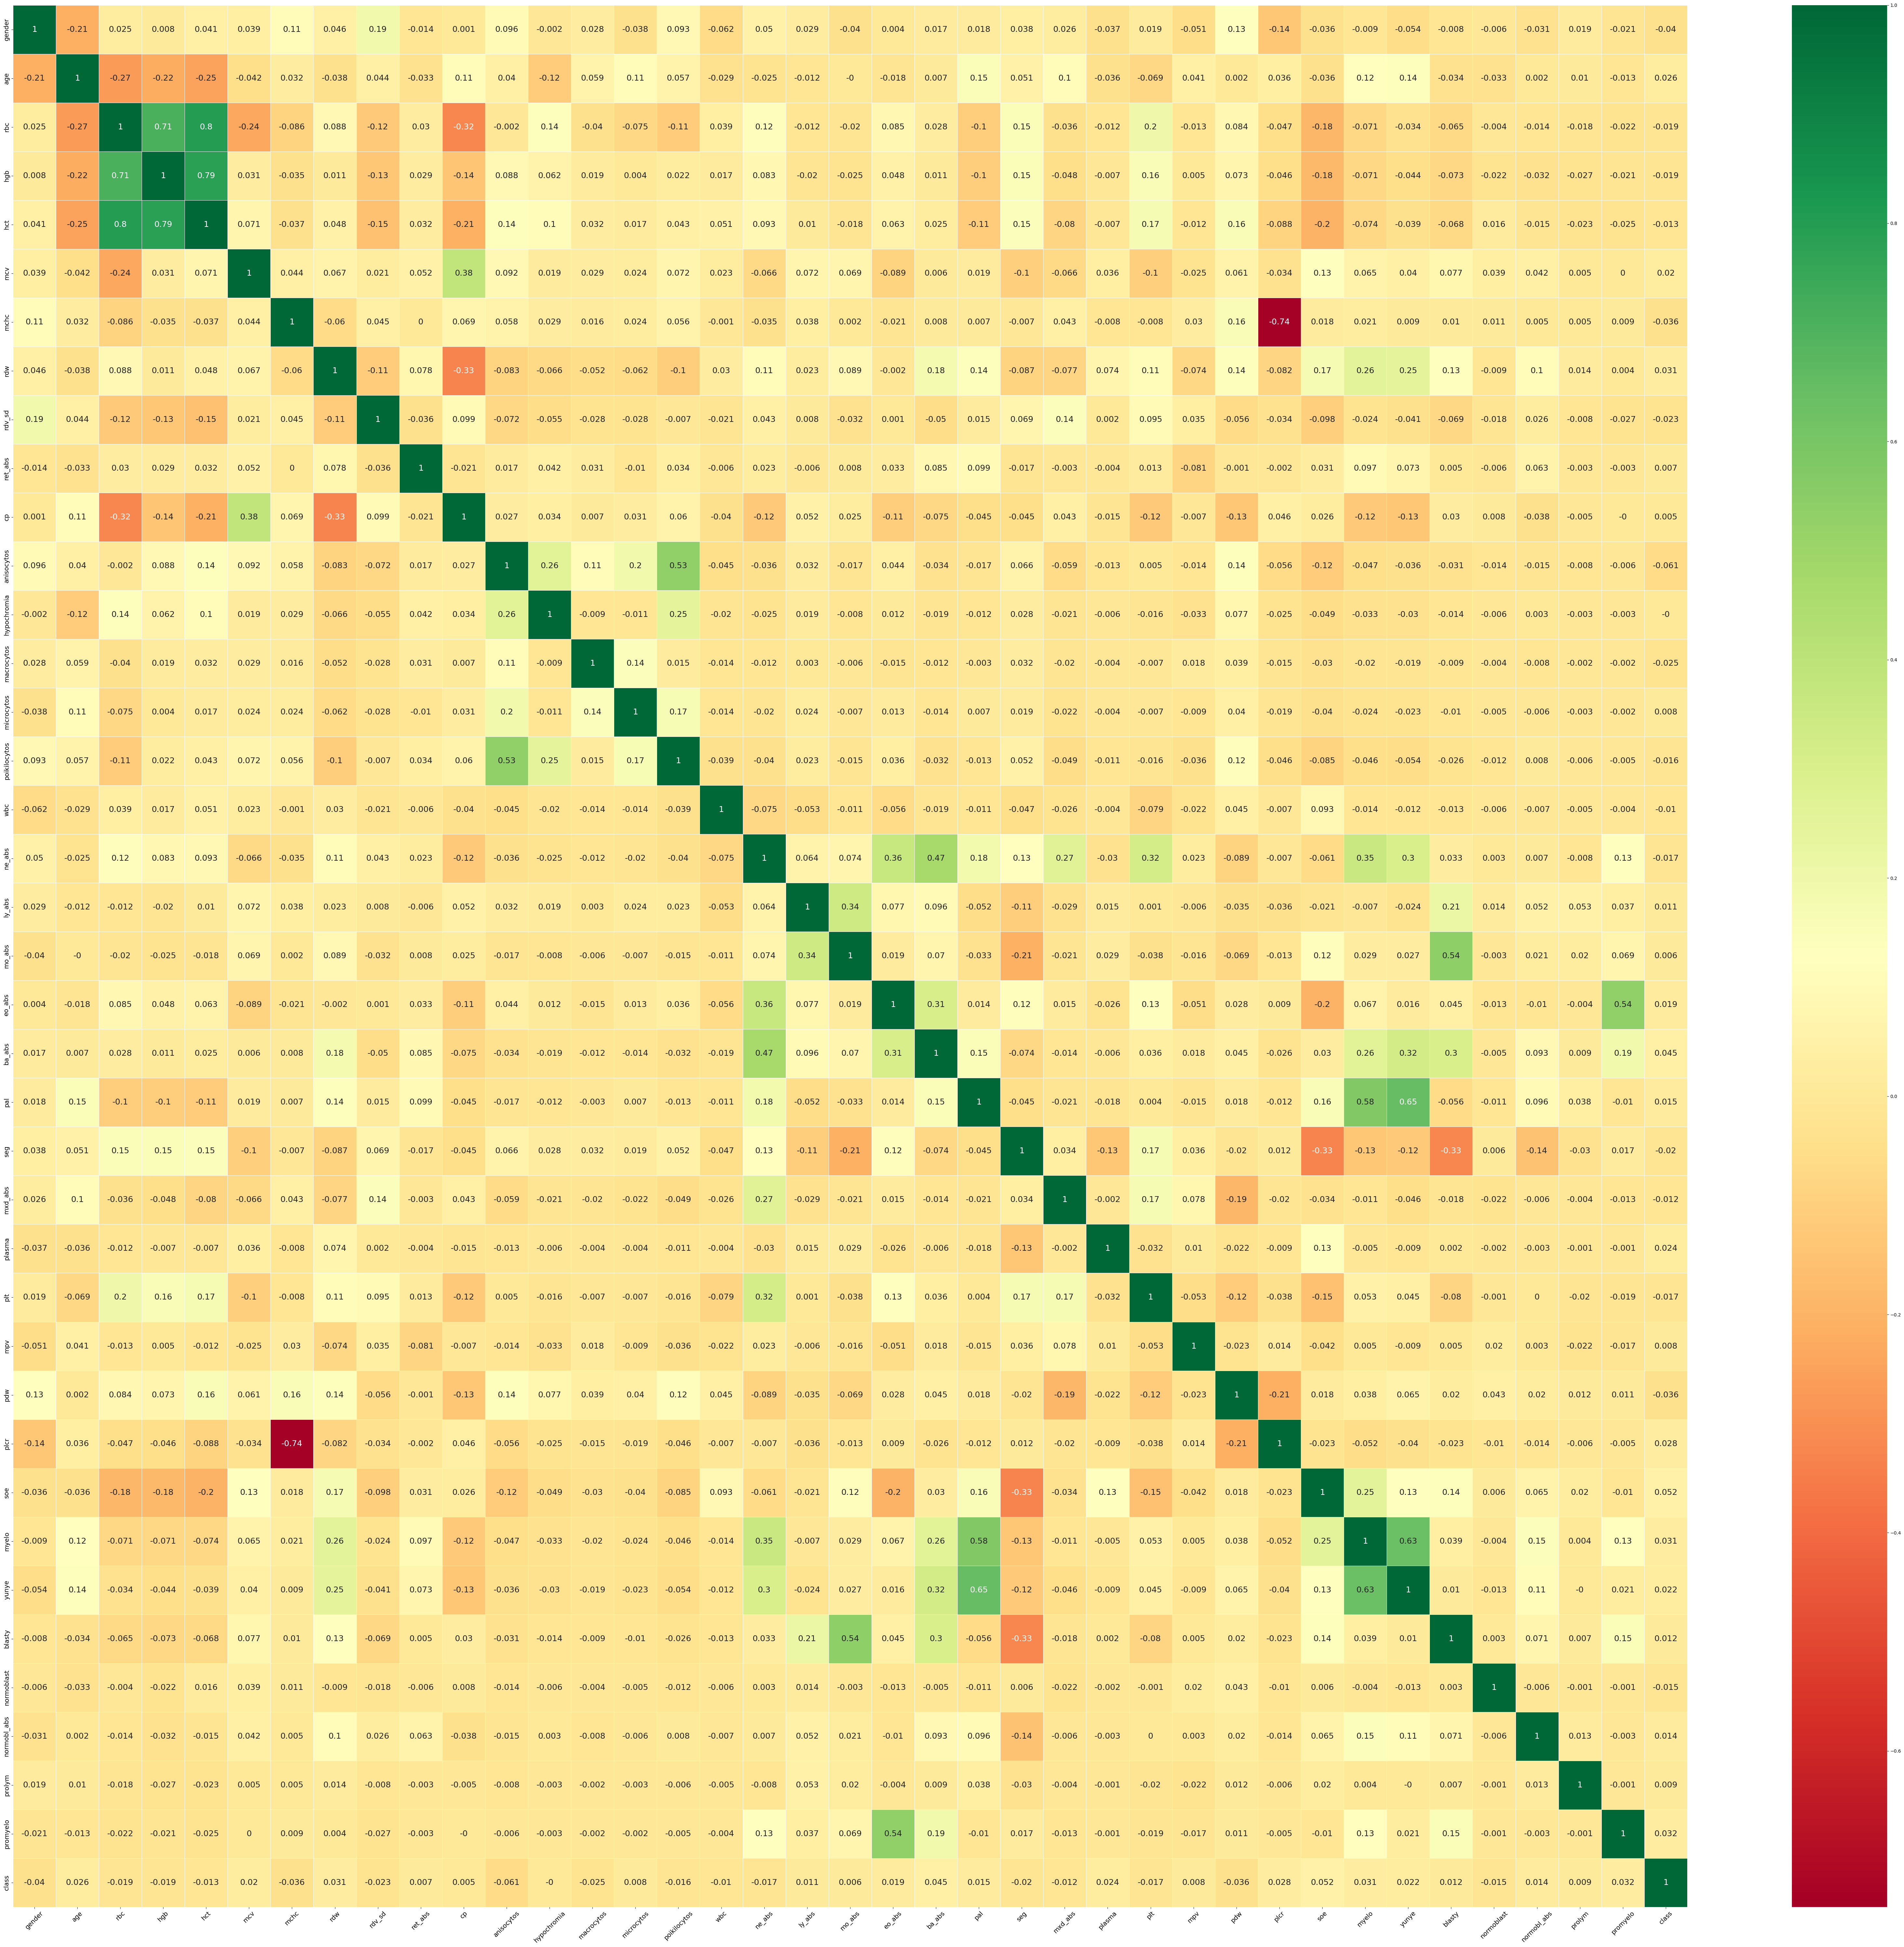

In [72]:
corr_matrix_df = round(df.corr(), 3)

fig, ax = plt.subplots(figsize=(65, 60))
sns.heatmap(
    corr_matrix_df,
    annot=True,
    cmap='RdYlGn',
    annot_kws={"fontsize": 18},
    xticklabels=corr_matrix_df.columns,
    yticklabels=corr_matrix_df.index,
    linewidths=.5
)
ax.tick_params(axis="x", labelrotation=45, labelsize=14)
ax.tick_params(axis="y", labelsize=14)
plt.tight_layout()
plt.show()

In [73]:
#выведем пары с корреляцией выше 0.5
threshold = 0.5

high_correlations = (
    corr_matrix_df
    .stack()
    .reset_index()
    .rename(columns={0:'Корреляция'})
    .query('level_0 != level_1')
    .query(f'abs(Корреляция) >= {threshold}')
)

result = high_correlations.sort_values(by='Корреляция', ascending=False)[['level_0', 'level_1', 'Корреляция']]
display(result)
print(f'Количество пар с корреляцией выше 0.5 {len(result)} штук')

,level_0,level_1,Корреляция
82,rbc,hct,0.801
158,hct,rbc,0.801
159,hct,hgb,0.785
121,hgb,hct,0.785
119,hgb,rbc,0.714
81,rbc,hgb,0.714
1270,yunye,pal,0.646
890,pal,yunye,0.646
1241,myelo,yunye,0.634
1279,yunye,myelo,0.634


Количество пар с корреляцией выше 0.5 20 штук


Учитывая протеворечивость QR-разложения и матрицы корреляций, связь внутри данных не является линейной.

##Обучение модели

In [74]:
RANDOM_STATE = 42

In [75]:
df.head(2)

,gender,age,rbc,hgb,hct,mcv,mchc,rdw,rdv_sd,ret_abs,cp,anisocytos,hypochromia,macrocytos,microcytos,poikilocytos,wbc,ne_abs,ly_abs,mo_abs,eo_abs,ba_abs,pal,seg,mxd_abs,plasma,plt,mpv,pdw,plcr,soe,myelo,yunye,blasty,normoblast,normobl_abs,prolym,promyelo,class
0,0,87,2.21,84.0,26.3,119.1,320.0,21.30,52.14,0.0,1.14,0.0,0.0,0.0,0.0,0.0,10.0,6.50,1.30,1.50,0.20,0.00,3.00,67.00,0.52,0.0,100.0,9.66,15.04,0.0,12.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,3
1,0,87,1.91,74.0,23.6,123.8,315.0,12.28,41.11,0.0,0.91,0.0,0.0,0.0,0.0,0.0,9.1,4.12,1.59,0.52,0.13,0.01,2.61,66.94,0.69,0.0,264.4,7.85,15.50,0.0,7.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [76]:
numeric_data = df[num_col].copy()

In [77]:
min_max = MinMaxScaler()
scaled_features = min_max.fit_transform(numeric_data)

In [78]:
normalized_data = pd.DataFrame(scaled_features, columns=numeric_data.columns)

In [79]:
final_data = pd.concat([normalized_data, df[cat_col], df [bool_col]], axis=1)

In [80]:
X = final_data.drop(['class'], axis = 1)
y = final_data['class']

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [82]:
model = RandomForestClassifier(random_state=RANDOM_STATE)

In [83]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [84]:
# %%time
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
# mean_accuracy = grid_search.scores.mean()
print('Лучшие гиперпараметры:', best_params)
# print('Точность на обучающем наборе гиперпараметры:', mean_accuracy)

best_model = grid_search.best_estimator_

test_accuracy = best_model.score(X_test, y_test)
print(f'Точность на тестовом наборе: {test_accuracy:.2f}')

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Лучшие гиперпараметры: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Точность на тестовом наборе: 0.27


In [86]:
X_test.columns

Index(['age', 'rbc', 'hgb', 'hct', 'mcv', 'mchc', 'rdw', 'rdv_sd', 'ret_abs',
       'cp', 'wbc', 'ne_abs', 'ly_abs', 'mo_abs', 'eo_abs', 'ba_abs', 'pal',
       'seg', 'mxd_abs', 'plasma', 'plt', 'mpv', 'pdw', 'plcr', 'soe', 'myelo',
       'yunye', 'blasty', 'normobl_abs', 'gender', 'anisocytos', 'hypochromia',
       'macrocytos', 'microcytos', 'poikilocytos', 'normoblast', 'promyelo'],
      dtype='object')

In [87]:
best_model

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [88]:
import joblib
joblib.dump(best_model, 'inference/best_model.pkl')

['inference/best_model.pkl']

In [85]:
print('Код не упал!')

Код не упал!
